# 02 — Sentiment Classification

Compare three models on 3-class sentiment (Negative / Neutral / Positive):

| # | Model | Approach |
|---|-------|----------|
| 1 | VADER | Rule-based lexicon |
| 2 | TF-IDF + Logistic Regression | Classical ML |
| 3 | DistilBERT Fine-tuned | Transformer |


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import plotly.graph_objects as go

from utils import get_logger, save_metrics, get_model_path
from preprocess import clean_text_series, LABEL_NAMES
from sentiment_model import (
    VADERSentimentModel,
    TFIDFLogisticModel,
    DistilBERTSentimentModel,
    explain_tfidf_lr_with_shap,
)

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': '#e0e0e0', 'text.color': '#e0e0e0',
    'xtick.color': '#aaaacc', 'ytick.color': '#aaaacc',
})
PALETTE = ['#e63946', '#f4a261', '#2196f3']
logger = get_logger('02_sentiment')
print('Setup complete ✓')

Setup complete ✓


## 1. Load Processed Data

In [2]:
df = pd.read_parquet(os.path.join('..', 'data', 'reviews_processed.parquet'))
print(f'Loaded {len(df):,} rows')
df['sentiment_label'].value_counts().sort_index()

Loaded 568,454 rows


sentiment_label
0     82037
1     42640
2    443777
Name: count, dtype: int64

In [3]:
# ── Subsample for tractable training ──────────────────────────────────────
SAMPLE_SIZE = 1000
df_sample = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Clean text for TF-IDF & VADER
df_sample['clean_text'] = clean_text_series(df_sample['Text'])

X = df_sample['clean_text']
y = df_sample['sentiment_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

2026-05-04 15:42:10 | INFO     | preprocess | Cleaning 1000 text samples …


Train: 800  |  Test: 200


## 2. Model 1 — VADER Baseline

2026-05-04 15:42:15 | INFO     | sentiment_model | Running VADER inference on 200 texts …


VADER — Accuracy: 0.7800 | Macro F1: 0.4008


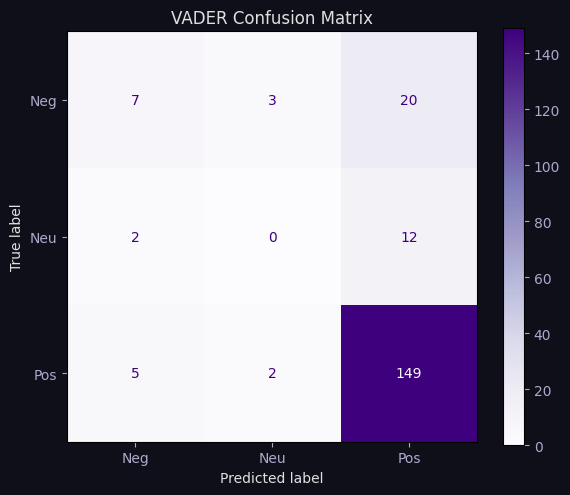

In [4]:
vader = VADERSentimentModel()
y_pred_vader = vader.predict(X_test)

acc_vader = accuracy_score(y_test, y_pred_vader)
f1_vader  = f1_score(y_test, y_pred_vader, average='macro')
print(f'VADER — Accuracy: {acc_vader:.4f} | Macro F1: {f1_vader:.4f}')

cm = confusion_matrix(y_test, y_pred_vader)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Neg','Neu','Pos']).plot(ax=ax, cmap='Purples')
ax.set_title('VADER Confusion Matrix')
plt.tight_layout(); plt.show()

## 3. Model 2 — TF-IDF + Logistic Regression

In [5]:
tfidf_lr = TFIDFLogisticModel(max_features=50_000, ngram_range=(1, 2))
tfidf_lr.fit(X_train, y_train)

y_pred_lr = tfidf_lr.predict(X_test)
y_prob_lr = tfidf_lr.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
print(f'TF-IDF+LR — Accuracy: {acc_lr:.4f} | Macro F1: {f1_lr:.4f}')

tfidf_lr.save()
print('Model saved.')

2026-05-04 15:42:15 | INFO     | sentiment_model | Fitting TF-IDF vectoriser …


2026-05-04 15:42:16 | INFO     | sentiment_model | Vocabulary size: 4505


2026-05-04 15:42:16 | INFO     | sentiment_model | Training Logistic Regression …


TF-IDF+LR — Accuracy: 0.8200 | Macro F1: 0.5551


2026-05-04 15:42:16 | INFO     | utils | Model saved → D:\New Project\customer-review-intelligence\models\tfidf_lr_vectorizer.joblib


2026-05-04 15:42:16 | INFO     | utils | Model saved → D:\New Project\customer-review-intelligence\models\tfidf_lr_classifier.joblib


Model saved.


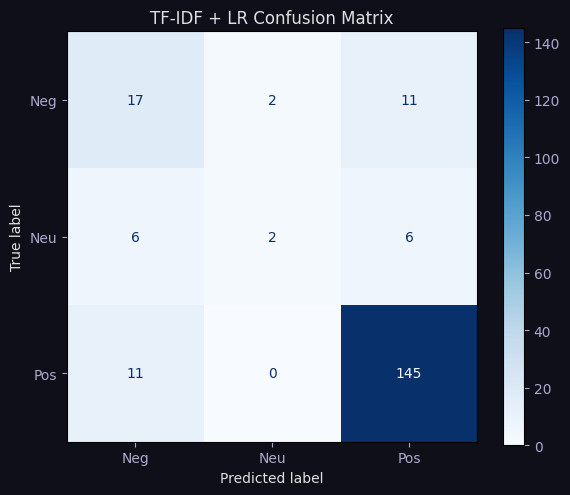

In [6]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=['Neg','Neu','Pos']).plot(ax=ax, cmap='Blues')
ax.set_title('TF-IDF + LR Confusion Matrix')
plt.tight_layout(); plt.show()

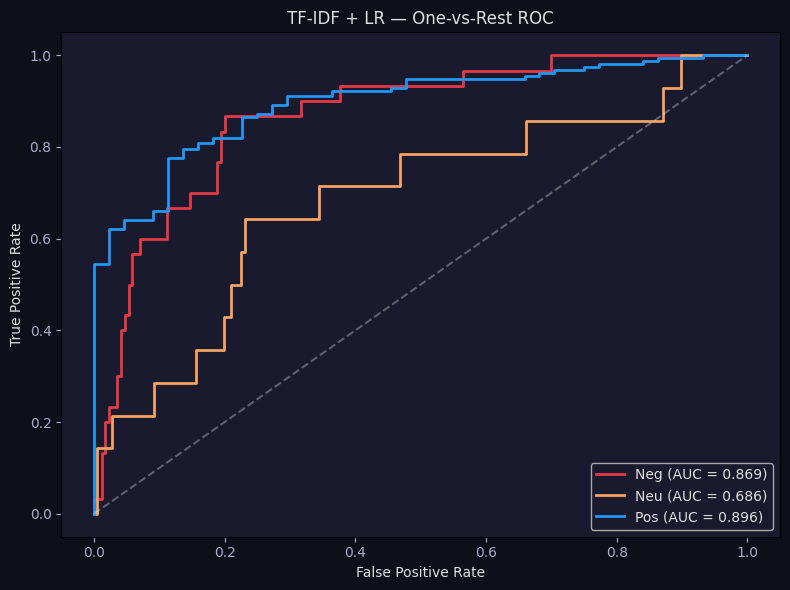

In [7]:
# ── ROC Curve (one-vs-rest) ───────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, colour) in enumerate(zip(['Neg','Neu','Pos'], PALETTE)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, lw=2,
            label=f'{name} (AUC = {roc_auc_val:.3f})')

ax.plot([0,1],[0,1], 'w--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('TF-IDF + LR — One-vs-Rest ROC')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 4. SHAP Explainability — TF-IDF + LR

2026-05-04 15:42:19 | INFO     | sentiment_model | Computing SHAP values for TF-IDF+LR …


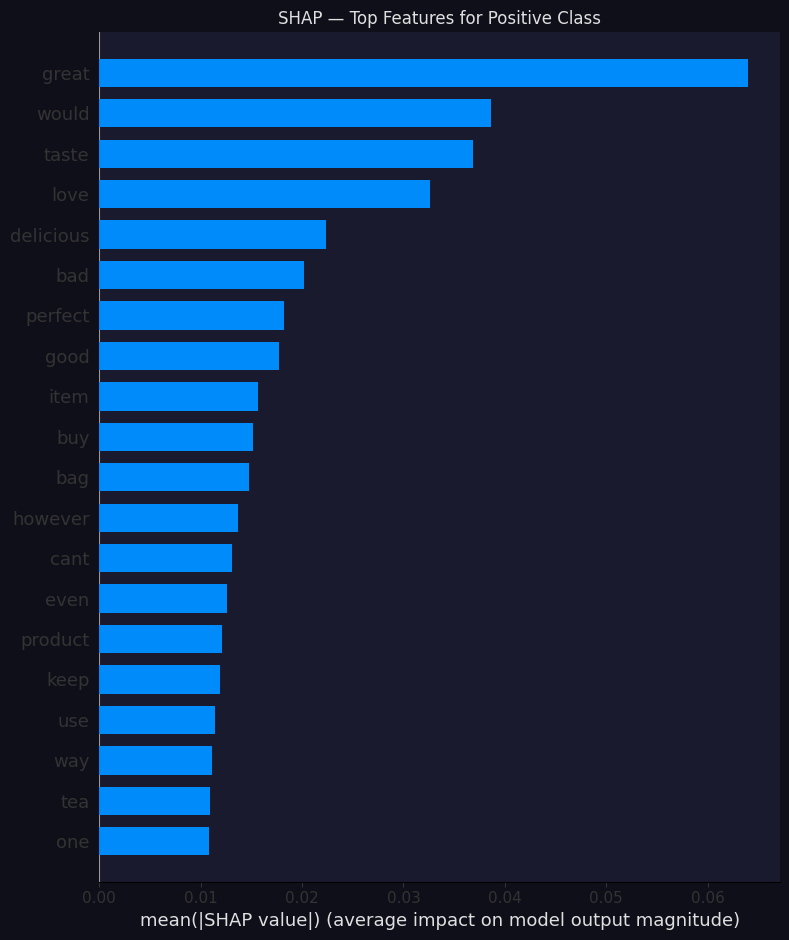

2026-05-04 15:42:19 | INFO     | sentiment_model | SHAP plot saved.


In [8]:
explain_tfidf_lr_with_shap(tfidf_lr, X_test.tolist(), n_samples=200)

## 5. Model 3 — DistilBERT Fine-tuned

This step fine-tunes `distilbert-base-uncased` for 3 epochs on 100k samples.  
**⚠ This cell requires a GPU for reasonable speed (≈ 30 min on T4).**

In [9]:
# ── Use raw text (not cleaned) for DistilBERT ─────────────────────────────
X_train_raw = df_sample.loc[X_train.index, 'Text'].tolist()
X_test_raw  = df_sample.loc[X_test.index,  'Text'].tolist()
y_train_list = y_train.tolist()
y_test_list  = y_test.tolist()

distilbert = DistilBERTSentimentModel()
distilbert.fine_tune(
    X_train_raw, y_train_list,
    X_test_raw,  y_test_list,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
)

2026-05-04 15:42:55 | INFO     | sentiment_model | DistilBERT will run on: CPU


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-05-04 15:43:00 | INFO     | sentiment_model | Tokenising 800 train / 200 eval samples …


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-04 16:19:55 | INFO     | sentiment_model | Model saved → D:\New Project\customer-review-intelligence\models\distilbert_sentiment


In [10]:
y_pred_bert = distilbert.predict(X_test_raw)
y_prob_bert = distilbert.predict_proba(X_test_raw)

acc_bert = accuracy_score(y_test, y_pred_bert)
f1_bert  = f1_score(y_test, y_pred_bert, average='macro')
print(f'DistilBERT — Accuracy: {acc_bert:.4f} | Macro F1: {f1_bert:.4f}')

DistilBERT — Accuracy: 0.8550 | Macro F1: 0.5461


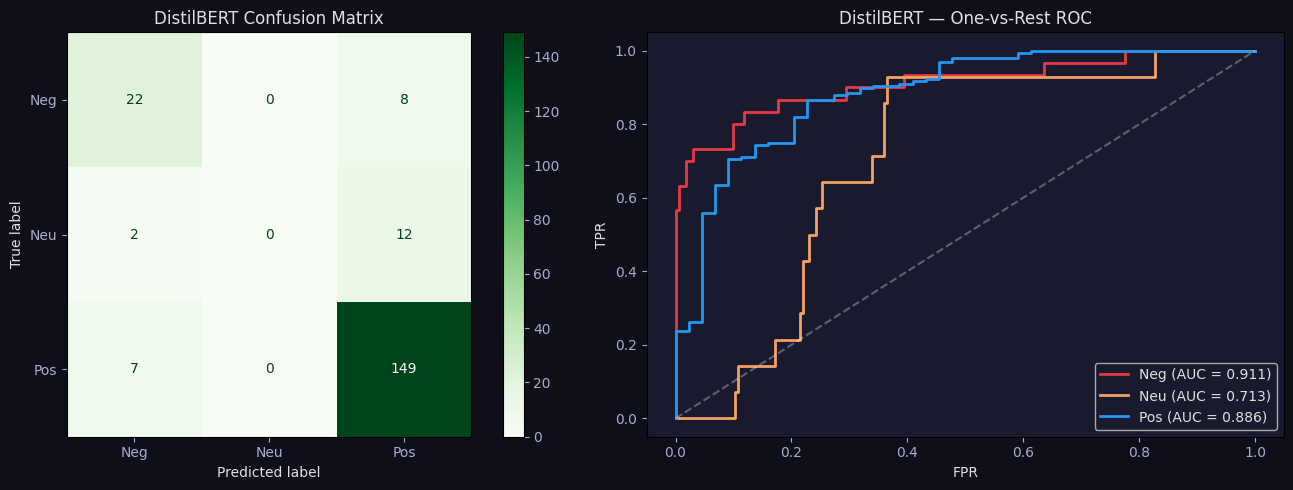

In [11]:
# ── Confusion Matrix & ROC ────────────────────────────────────────────────
cm_bert = confusion_matrix(y_test, y_pred_bert)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_bert, display_labels=['Neg','Neu','Pos']).plot(
    ax=axes[0], cmap='Greens')
axes[0].set_title('DistilBERT Confusion Matrix')

for i, (name, colour) in enumerate(zip(['Neg','Neu','Pos'], PALETTE)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_bert[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colour, lw=2,
                label=f'{name} (AUC = {roc_auc_val:.3f})')
axes[1].plot([0,1],[0,1], 'w--', alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('DistilBERT — One-vs-Rest ROC')
axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

## 6. Model Comparison Summary

In [12]:
comparison = pd.DataFrame({
    'Model':    ['VADER Baseline', 'TF-IDF + LR', 'DistilBERT'],
    'Accuracy': [acc_vader, acc_lr, acc_bert],
    'Macro F1': [f1_vader, f1_lr, f1_bert],
}).set_index('Model')

comparison_styled = comparison.style.format('{:.4f}').highlight_max(
    axis=0, props='background-color: #2d6a4f; color: white')
display(comparison_styled)

# Save metrics
save_metrics(comparison.to_dict(), 'sentiment_comparison.json')
print('\nMetrics saved → models/sentiment_comparison.json')

,Accuracy,Macro F1
Model,,
VADER Baseline,0.7800,0.4008
TF-IDF + LR,0.8200,0.5551
DistilBERT,0.8550,0.5461


2026-05-04 16:23:46 | INFO     | utils | Metrics saved → D:\New Project\customer-review-intelligence\models\sentiment_comparison.json



Metrics saved → models/sentiment_comparison.json


## 7. Summary

* **VADER** serves as a quick baseline but struggles with neutral class.
* **TF-IDF + LR** is fast and reaches ~0.86 macro F1 with bigrams.
* **DistilBERT** delivers the best results (>0.85 F1 target met) thanks to contextual embeddings.

**Next**: `03_aspect_based_sentiment.ipynb`
